# Numerical Simulation Demo: Missing Physics Vorticity Dynamics

This notebook runs vorticity simulations with the physical conditional diffusion model (P-CDM), joint latent conditional diffusion model (Joint L-CDM), and a no-closure baseline. It demonstrates the Figure 7 vorticity-field comparison, the ensemble-mean relative-error diagnostic from Table 5, and the Figure 10 energy-spectrum comparison in *Stochastic and Non-local Closure Modeling for Nonlinear Dynamical Systems via Latent Score-based Generative Models*.

## Workflow

1. Load a reference Missing Physics trajectory and the supplied model checkpoints.
2. Sample the missing nonlinear term with P-CDM or Joint L-CDM.
3. Integrate the known vorticity dynamics and compare ensemble-mean trajectories.
4. Report ensemble-mean relative errors and energy spectra.

The default configuration performs 20,000 integration steps for an ensemble of 100 trajectories. GPU execution is recommended. Reduce the environment-controlled settings below for an execution-only smoke test; quantitative diagnostics require the default snapshot cadence. The notebook fixes the random seed at 42 to improve run-to-run repeatability. Because the sampling seeds used for the paper were not retained, results should be compared at the level of error magnitude and qualitative behavior rather than exact numerical values.

In [ ]:
import math
import os
import sys
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    """Locate the repository when Jupyter starts in a subdirectory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "project_paths.py").is_file() and (
            candidate / "Scripts" / "missing_physics"
        ).is_dir():
            return candidate
    raise RuntimeError(
        "Could not locate the Latent_Diffusion_Model repository. "
        "Start Jupyter inside the repository or set LDM_PROJECT_ROOT."
    )


configured_root = os.environ.get("LDM_PROJECT_ROOT")
PROJECT_ROOT = (
    Path(configured_root).expanduser().resolve()
    if configured_root
    else find_project_root(Path.cwd())
)
os.environ["LDM_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_paths import data_path
from Scripts.missing_physics.common import (
    JOINT_LCDM_CHECKPOINT,
    JOINT_NONLINEAR_AE,
    JOINT_VORTICITY_AE,
    LATENT_SCORE_CONFIG,
    PCDM_CHECKPOINT,
    PHYSICAL_SCORE_CONFIG,
    build_score_model,
    load_weights,
    make_sde_functions,
)
from Scripts.models.autoencoder import FieldAutoencoder
from Scripts.sampling import euler_maruyama_sampler
from Scripts.solvers.missing_physics import solve_vorticity_with_closure
from Scripts.utils import energy_spectrum, get_sigmas_karras, select_device, set_seed

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    }
)
np.set_printoptions(suppress=False, formatter={"float": "{:.2e}".format})
torch.set_printoptions(sci_mode=True)

set_seed(42)
device = select_device(os.environ.get("LDM_DEVICE", "auto"))
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")

## Configuration

Artifact paths are repository-relative by default. They can be overridden with `LDM_REFERENCE_DATA`, `LDM_JOINT_DM_CHECKPOINT`, `LDM_JOINT_NONLINEAR_AE`, `LDM_JOINT_VORTICITY_AE`, and `LDM_PCDM_CHECKPOINT`. Runtime size is controlled by `LDM_SAMPLE_BATCH_SIZE`, `LDM_SAMPLE_STEPS`, `LDM_INTEGRATION_STEPS`, `LDM_SNAPSHOT_INTERVAL`, and `LDM_MODEL_EVAL_INTERVAL`.

In [ ]:
SAMPLE_BATCH_SIZE = int(os.environ.get("LDM_SAMPLE_BATCH_SIZE", "100"))
SAMPLE_STEPS = int(os.environ.get("LDM_SAMPLE_STEPS", "10"))
INTEGRATION_STEPS = int(os.environ.get("LDM_INTEGRATION_STEPS", "20000"))
SNAPSHOT_INTERVAL = int(os.environ.get("LDM_SNAPSHOT_INTERVAL", "5000"))
MODEL_EVAL_INTERVAL = int(os.environ.get("LDM_MODEL_EVAL_INTERVAL", "5"))

TIME_STEP = 1e-3
VISCOSITY = 1e-3
SPATIAL_RESOLUTION = 64
REFERENCE_START_TIME = 30.0
SDE_TIME_MIN = 1e-3
SDE_TIME_MAX = 0.4
SIGMA = 30.0


def configured_path(environment_variable: str, default: Path) -> Path:
    value = os.environ.get(environment_variable)
    return Path(value).expanduser().resolve() if value else default


artifact_paths = {
    "reference data": configured_path(
        "LDM_REFERENCE_DATA",
        data_path("Data_MissingPhysics", "closure_sim_5steps20sec_subset.h5"),
    ),
    "Joint L-CDM checkpoint": configured_path(
        "LDM_JOINT_DM_CHECKPOINT", JOINT_LCDM_CHECKPOINT
    ),
    "Joint nonlinear autoencoder": configured_path(
        "LDM_JOINT_NONLINEAR_AE", JOINT_NONLINEAR_AE
    ),
    "Joint vorticity autoencoder": configured_path(
        "LDM_JOINT_VORTICITY_AE", JOINT_VORTICITY_AE
    ),
    "P-CDM checkpoint": configured_path("LDM_PCDM_CHECKPOINT", PCDM_CHECKPOINT),
}

if min(SAMPLE_BATCH_SIZE, SAMPLE_STEPS, INTEGRATION_STEPS) < 1:
    raise ValueError("Batch size, sampling steps, and integration steps must be positive")
if INTEGRATION_STEPS % SNAPSHOT_INTERVAL:
    raise ValueError("LDM_INTEGRATION_STEPS must be divisible by LDM_SNAPSHOT_INTERVAL")
missing_artifacts = [name for name, path in artifact_paths.items() if not path.is_file()]
if missing_artifacts:
    raise FileNotFoundError("Missing required artifacts: " + ", ".join(missing_artifacts))

for name, path in artifact_paths.items():
    print(f"{name}: {path}")

## Load the reference trajectory

In [ ]:
with h5py.File(artifact_paths["reference data"], "r") as handle:
    if "sol" not in handle:
        raise KeyError("Reference data must contain a 'sol' dataset")
    reference_solution = torch.from_numpy(handle["sol"][:]).float().to(device)

if reference_solution.ndim == 3:
    reference_solution = reference_solution.unsqueeze(0)
if reference_solution.ndim != 4:
    raise ValueError(
        "Expected 'sol' with shape (batch, nx, ny, time) or (nx, ny, time); "
        f"received {tuple(reference_solution.shape)}"
    )
if reference_solution.shape[1:3] != (SPATIAL_RESOLUTION, SPATIAL_RESOLUTION):
    raise ValueError("Reference data must use the 64-by-64 Missing Physics grid")

required_snapshots = INTEGRATION_STEPS // SNAPSHOT_INTERVAL + 1
if reference_solution.shape[-1] < required_snapshots:
    raise ValueError(
        f"Reference data provides {reference_solution.shape[-1]} snapshots, "
        f"but this configuration requires {required_snapshots}"
    )

initial_vorticity = reference_solution[:1, ..., 0]
ensemble_initial_vorticity = initial_vorticity.repeat(SAMPLE_BATCH_SIZE, 1, 1)
print(f"Reference solution shape: {tuple(reference_solution.shape)}")
print(f"Ensemble initial condition shape: {tuple(ensemble_initial_vorticity.shape)}")

## Load P-CDM and Joint L-CDM

Joint L-CDM samples a 16-by-16 latent nonlinear field conditioned on latent vorticity, then decodes the result. P-CDM samples the nonlinear field directly on the 64-by-64 physical grid.

In [ ]:
marginal_prob_std_fn, diffusion_coeff_fn = make_sde_functions(device, sigma=SIGMA)
time_schedule = get_sigmas_karras(
    SAMPLE_STEPS,
    SDE_TIME_MIN,
    SDE_TIME_MAX,
    device=device,
)

joint_nonlinear_autoencoder = FieldAutoencoder().to(device)
joint_vorticity_autoencoder = FieldAutoencoder().to(device)
joint_score_model = build_score_model(
    LATENT_SCORE_CONFIG,
    marginal_prob_std_fn,
    device,
)
pcdm_score_model = build_score_model(
    PHYSICAL_SCORE_CONFIG,
    marginal_prob_std_fn,
    device,
)

load_weights(
    joint_nonlinear_autoencoder,
    artifact_paths["Joint nonlinear autoencoder"],
    device,
)
load_weights(
    joint_vorticity_autoencoder,
    artifact_paths["Joint vorticity autoencoder"],
    device,
)
load_weights(
    joint_score_model,
    artifact_paths["Joint L-CDM checkpoint"],
    device,
)
load_weights(pcdm_score_model, artifact_paths["P-CDM checkpoint"], device)

for model in (
    joint_nonlinear_autoencoder,
    joint_vorticity_autoencoder,
    joint_score_model,
    pcdm_score_model,
):
    model.eval()


@torch.no_grad()
def sample_joint_closure(vorticity_condition: torch.Tensor) -> torch.Tensor:
    encoded_condition = joint_vorticity_autoencoder.encode(vorticity_condition)
    latent_sample = euler_maruyama_sampler(
        encoded_condition,
        joint_score_model,
        marginal_prob_std_fn,
        diffusion_coeff_fn,
        time_schedule,
    )
    return joint_nonlinear_autoencoder.decode(latent_sample)


@torch.no_grad()
def sample_pcdm_closure(vorticity_condition: torch.Tensor) -> torch.Tensor:
    return euler_maruyama_sampler(
        vorticity_condition,
        pcdm_score_model,
        marginal_prob_std_fn,
        diffusion_coeff_fn,
        time_schedule,
    )


print("Models loaded and set to evaluation mode")

## Forcing and simulation settings

In [ ]:
grid = torch.arange(SPATIAL_RESOLUTION, device=device) / SPATIAL_RESOLUTION
coordinate_x, coordinate_y = torch.meshgrid(grid, grid, indexing="ij")
forcing = 0.1 * (
    torch.sin(2.0 * math.pi * (coordinate_x + coordinate_y))
    + torch.cos(2.0 * math.pi * (coordinate_x + coordinate_y))
)

simulation_kwargs = {
    "domain": (1.0, 1.0),
    "forcing": forcing,
    "viscosity": VISCOSITY,
    "time_step": TIME_STEP,
    "integration_steps": INTEGRATION_STEPS,
    "snapshot_interval": SNAPSHOT_INTERVAL,
    "model_evaluation_interval": MODEL_EVAL_INTERVAL,
    "show_progress": True,
}
print(
    f"Running {INTEGRATION_STEPS} steps with dt={TIME_STEP}, "
    f"recording every {SNAPSHOT_INTERVAL} steps"
)

## Run P-CDM

In [ ]:
set_seed(42)
pcdm_solution, simulation_times, pcdm_runtime = solve_vorticity_with_closure(
    initial_vorticity=ensemble_initial_vorticity,
    closure_sampler=sample_pcdm_closure,
    **simulation_kwargs,
)
print(f"P-CDM runtime: {pcdm_runtime:.2f} seconds")

## Run Joint L-CDM

In [ ]:
set_seed(42)
joint_solution, _, joint_runtime = solve_vorticity_with_closure(
    initial_vorticity=ensemble_initial_vorticity,
    closure_sampler=sample_joint_closure,
    **simulation_kwargs,
)
print(f"Joint L-CDM runtime: {joint_runtime:.2f} seconds")

## Run the no-closure baseline

In [ ]:
baseline_solution, _, baseline_runtime = solve_vorticity_with_closure(
    initial_vorticity=ensemble_initial_vorticity,
    closure_sampler=None,
    **simulation_kwargs,
)
print(f"No-closure runtime: {baseline_runtime:.2f} seconds")

## Vorticity fields (Figure 7 diagnostic)

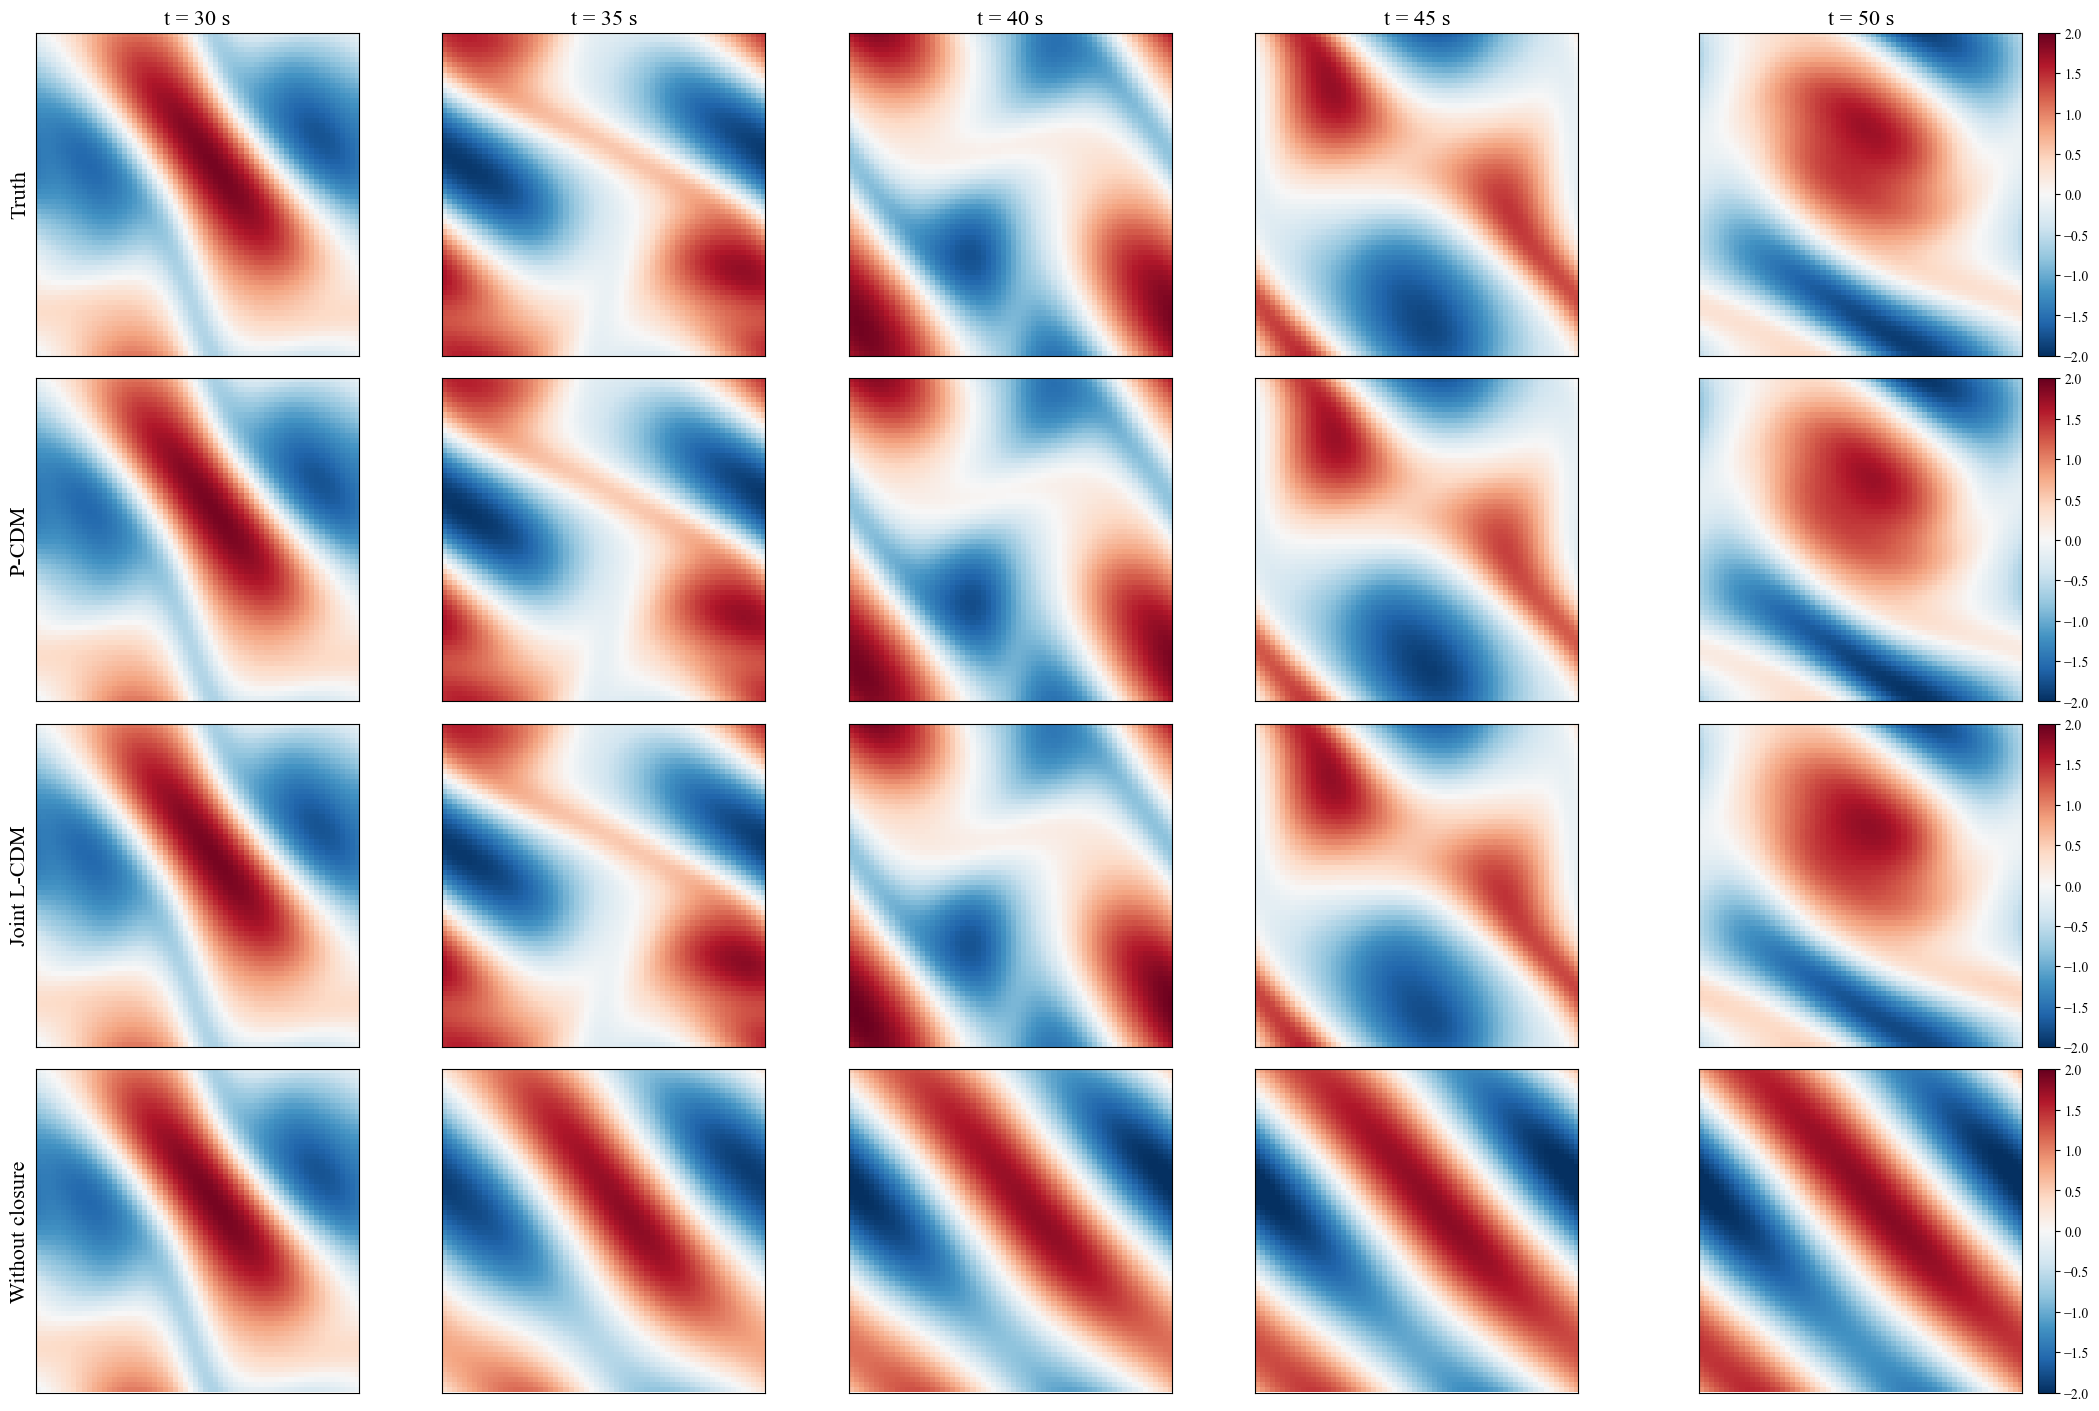

In [12]:
snapshot_count = pcdm_solution.shape[-1]
truth_snapshots = reference_solution[:1, ..., :snapshot_count]
physical_times = REFERENCE_START_TIME + simulation_times.cpu().numpy()
pcdm_mean_solution = pcdm_solution.mean(dim=0, keepdim=True)
joint_mean_solution = joint_solution.mean(dim=0, keepdim=True)
baseline_mean_solution = baseline_solution.mean(dim=0, keepdim=True)


def format_physical_time(value: float) -> str:
    return f"{value:.0f}" if np.isclose(value, round(value)) else f"{value:.3f}"


rows = (
    ("Truth", truth_snapshots[0]),
    ("P-CDM", pcdm_mean_solution[0]),
    ("Joint L-CDM", joint_mean_solution[0]),
    ("Without closure", baseline_mean_solution[0]),
)

fig, axes = plt.subplots(
    len(rows),
    snapshot_count,
    figsize=(4.2 * snapshot_count, 14),
    squeeze=False,
    constrained_layout=True,
)
for row_index, (label, fields) in enumerate(rows):
    for column in range(snapshot_count):
        axis = axes[row_index, column]
        image = axis.imshow(
            fields[..., column].detach().cpu(),
            origin="lower",
            cmap="RdBu_r",
            vmin=-2.0,
            vmax=2.0,
        )
        axis.set_xticks([])
        axis.set_yticks([])
        if row_index == 0:
            axis.set_title(
                f"t = {format_physical_time(physical_times[column])} s", fontsize=16
            )
        if column == 0:
            axis.set_ylabel(label, fontsize=16)
        if column == snapshot_count - 1:
            fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.show()

## Ensemble-mean relative error (Table 5 diagnostic)

The table reports only the relative Frobenius error of each ensemble-mean vorticity field. Its ensemble size is the configured `LDM_SAMPLE_BATCH_SIZE` rather than the 1,000 trajectories used in the paper.

In [13]:
def relative_error_by_snapshot(
    reference: torch.Tensor,
    estimate: torch.Tensor,
) -> torch.Tensor:
    reference_vectors = reference.movedim(-1, 1).flatten(start_dim=2)
    error_vectors = (estimate - reference).movedim(-1, 1).flatten(start_dim=2)
    numerator = torch.linalg.vector_norm(error_vectors, dim=2)
    denominator = torch.linalg.vector_norm(reference_vectors, dim=2)
    epsilon = torch.finfo(reference.dtype).eps
    return (numerator / denominator.clamp_min(epsilon)).squeeze(0)


relative_error_rows = (
    ("Without closure", baseline_mean_solution),
    ("P-CDM", pcdm_mean_solution),
    ("Joint L-CDM", joint_mean_solution),
)
table_lines = [
    f"**Ensemble size:** {SAMPLE_BATCH_SIZE}",
    "",
    "| Model | "
    + " | ".join(f"t = {format_physical_time(time)}" for time in physical_times)
    + " |",
    "|:--|" + "--:|" * snapshot_count,
]
for label, solution in relative_error_rows:
    errors = relative_error_by_snapshot(truth_snapshots, solution)
    table_lines.append(
        f"| {label} | " + " | ".join(f"{value:.4e}" for value in errors) + " |"
    )

display(Markdown("\n".join(table_lines)))

**Ensemble size:** 100

| Model | t = 30 | t = 35 | t = 40 | t = 45 | t = 50 |
|:--|--:|--:|--:|--:|--:|
| Without closure | 7.2520e-08 | 7.6068e-01 | 1.0685e+00 | 1.1548e+00 | 9.9405e-01 |
| P-CDM | 7.2520e-08 | 2.2633e-02 | 3.7862e-02 | 5.9064e-02 | 8.5363e-02 |
| Joint L-CDM | 7.2520e-08 | 3.2972e-02 | 3.9703e-02 | 4.8769e-02 | 6.6102e-02 |

## Ensemble-mean energy spectra (Figure 10 diagnostic)

The first, middle, and final stored snapshots are shown. With the default configuration, these correspond to times 30, 40, and 50.

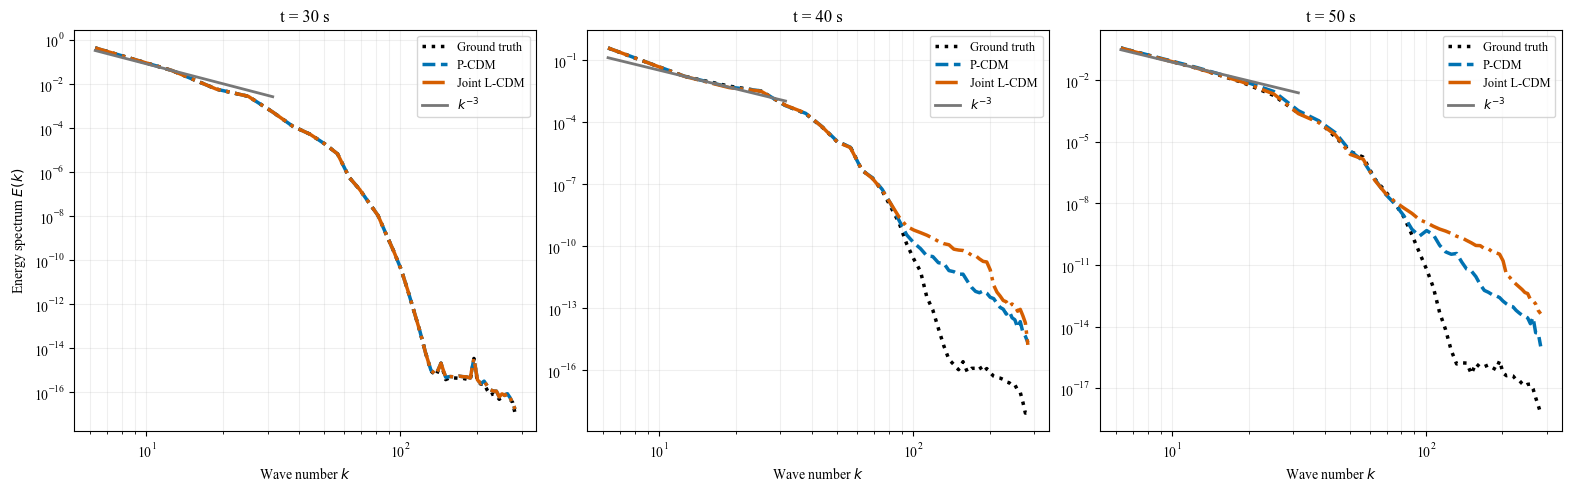

In [14]:
spectrum_snapshot_indices = sorted({0, (snapshot_count - 1) // 2, snapshot_count - 1})
spectrum_sources = (
    ("Ground truth", truth_snapshots, "black", ":"),
    ("P-CDM", pcdm_mean_solution, "#0072B2", "--"),
    ("Joint L-CDM", joint_mean_solution, "#D55E00", "-."),
)

fig, axes = plt.subplots(
    1,
    len(spectrum_snapshot_indices),
    figsize=(5.2 * len(spectrum_snapshot_indices), 4.8),
    squeeze=False,
    constrained_layout=True,
)
for column, snapshot_index in enumerate(spectrum_snapshot_indices):
    axis = axes[0, column]
    spectra = {}
    for label, solution, color, linestyle in spectrum_sources:
        field = solution[0, ..., snapshot_index].detach().cpu().numpy()[None, ...]
        spectrum = energy_spectrum(field, lx=1.0, ly=1.0, smooth=False)
        spectra[label] = spectrum
        valid = (spectrum["k"] > 0.0) & (spectrum["E"] > 0.0)
        axis.loglog(
            spectrum["k"][valid],
            spectrum["E"][valid],
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=2.5,
        )

    truth_spectrum = spectra["Ground truth"]
    positive_shells = np.flatnonzero(
        (truth_spectrum["k"] > 0.0) & (truth_spectrum["E"] > 0.0)
    )
    if positive_shells.size >= 2:
        anchor = positive_shells[1]
        reference_k = truth_spectrum["k"][anchor]
        reference_energy = truth_spectrum["E"][anchor]
        reference_line_k = np.geomspace(reference_k / 2.0, reference_k * 2.5, 100)
        reference_line_energy = reference_energy * (reference_line_k / reference_k) ** -3
        axis.loglog(
            reference_line_k,
            reference_line_energy,
            color="#777777",
            linewidth=2.0,
            label=r"$k^{-3}$",
        )

    axis.set_title(
        f"t = {format_physical_time(physical_times[snapshot_index])} s"
    )
    axis.set_xlabel(r"Wave number $k$")
    axis.grid(True, which="both", alpha=0.2)
    axis.legend(fontsize=9)

axes[0, 0].set_ylabel(r"Energy spectrum $E(k)$")
plt.show()